<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/COMPARISIONOFALLTHREESTOCKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_clean(filename):
    df = pd.read_csv(filename)

    df['Date'] = pd.to_datetime(df['Date'])

    df['Volume'] = df['Volume'].replace('-', np.nan)
    df['Volume'] = df['Volume'].str.replace(',', '', regex=False).astype(float)

    df = df.drop(columns=['Symbol', 'Turn Over'])

    return df.sort_values('Date').reset_index(drop=True)

nabil = load_and_clean("NABILONEYEARCSV.csv")
nlic  = load_and_clean("NLICONEYEARCSV.csv")
ntc   = load_and_clean("NTCONEYEARCSV.csv")

close = pd.DataFrame({
    'Date': nabil['Date'],
    'NABIL': nabil['Close'],
    'NLIC': nlic['Close'],
    'NTC': ntc['Close']
})

close = close.set_index('Date')

normalised = pd.DataFrame()

for col in ['NABIL', 'NLIC', 'NTC']:
    normalised[col] = close[col] / close[col].iloc[0] * 100

print(normalised.head())

                 NABIL        NLIC         NTC
Date                                          
2025-07-07  100.000000  100.000000  100.000000
2025-07-08   99.676102  100.024820  100.179875
2025-07-09  100.390287  101.239713  100.978663
2025-07-10  102.836623  101.531025  101.648462
2025-07-13  107.785624  100.316133  102.073299


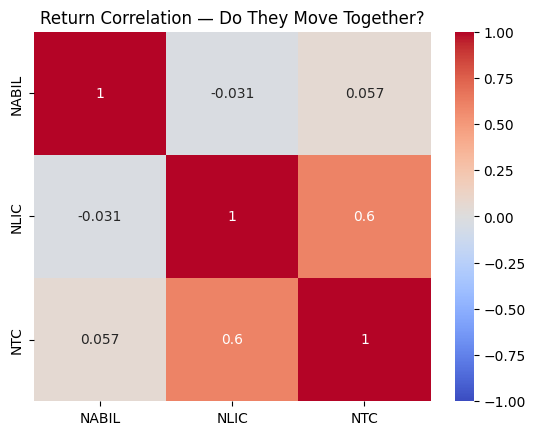

In [8]:

returns = close[['NABIL','NLIC','NTC']].pct_change().dropna()

sns.heatmap(returns.corr(), annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.title("Return Correlation — Do They Move Together?")
plt.show()
